## Setup e caricamento dati


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
import geopandas as gpd

OUTPUT_DIR = Path("dataset/cleaned/outputs")
FIG_DIR = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("OUTPUT_DIR:", OUTPUT_DIR.resolve())
print("FIG_DIR:", FIG_DIR.resolve())
print("OUTPUT_DIR exists?", OUTPUT_DIR.exists())

In [2]:
# lista dei file presenti in outputs

files = sorted([p.name for p in OUTPUT_DIR.iterdir()])

print("File trovati in dataset/cleaned/outputs:\n")
for f in files:
    print("-", f)

File trovati in dataset/cleaned/outputs:

- .DS_Store
- airport_communities.csv
- continent_directional_metrics.csv
- continent_flows.csv
- figures
- node_metrics.csv


In [4]:
# load outputs CSV

communities = pd.read_csv(OUTPUT_DIR / "airport_communities.csv")
node_metrics = pd.read_csv(OUTPUT_DIR / "node_metrics.csv")
continent_directional = pd.read_csv(OUTPUT_DIR / "continent_directional_metrics.csv")
continent_flows = pd.read_csv(OUTPUT_DIR / "continent_flows.csv")

print("airport_communities.csv:", communities.shape)
print("node_metrics.csv:", node_metrics.shape)
print("continent_directional_metrics.csv:", continent_directional.shape)
print("continent_flows.csv:", continent_flows.shape)

print("\n--- Columns ---")
print("communities:", list(communities.columns))
print("node_metrics:", list(node_metrics.columns))
print("continent_directional:", list(continent_directional.columns))
print("continent_flows:", list(continent_flows.columns))

airport_communities.csv: (3214, 2)
node_metrics.csv: (3214, 19)
continent_directional_metrics.csv: (6, 5)
continent_flows.csv: (34, 3)

--- Columns ---
communities: ['airport_id', 'community_id']
node_metrics: ['airport_id', 'in_degree', 'out_degree', 'in_strength', 'out_strength', 'out_in_ratio', 'pagerank', 'hits_hub', 'hits_authority', 'eigenvector', 'betweenness', 'name', 'city', 'country', 'iata', 'icao', 'latitude', 'longitude', 'continent']
continent_directional: ['continent', 'out_flow', 'in_flow', 'net_flow', 'out_in_ratio']
continent_flows: ['source_continent', 'target_continent', 'flow']


# Creazione dataset master aeroporti


In [5]:
# merge tra node_metrics e communities

airport_df = node_metrics.merge(
    communities,
    on="airport_id",
    how="left"
)

print("Shape airport_df:", airport_df.shape)
airport_df.head()

Shape airport_df: (3214, 20)


,airport_id,in_degree,out_degree,in_strength,out_strength,out_in_ratio,pagerank,hits_hub,hits_authority,eigenvector,betweenness,name,city,country,iata,icao,latitude,longitude,continent,community_id
0,1,4,4,5,5,1.000000,0.000214,0.000002,0.000002,0.000035,0.000000,Goroka Airport,Goroka,Papua New Guinea,GKA,AYGA,-6.081690,145.391998,Oceania,2
1,2,7,7,8,8,1.000000,0.000343,0.000001,0.000001,0.000018,0.000721,Madang Airport,Madang,Papua New Guinea,MAG,AYMD,-5.207080,145.789001,Oceania,2
2,3,9,8,12,10,0.888889,0.000483,0.000002,0.000002,0.000036,0.000009,Mount Hagen Kagamuga Airport,Mount Hagen,Papua New Guinea,HGU,AYMH,-5.826790,144.296005,Oceania,2
3,4,9,9,11,11,1.000000,0.000427,0.000002,0.000002,0.000036,0.000054,Nadzab Airport,Nadzab,Papua New Guinea,LAE,AYNZ,-6.569803,146.725977,Oceania,2
4,5,32,32,47,48,1.000000,0.001561,0.000170,0.000170,0.003059,0.023254,Port Moresby Jacksons International Airport,Port Moresby,Papua New Guinea,POM,AYPY,-9.443380,147.220001,Oceania,2


In [7]:
# sanity checks sul merge

print("Righe:", len(airport_df))
print("Airport_id unici:", airport_df["airport_id"].nunique())
print("NaN in community_id:", airport_df["community_id"].isna().sum())

# eventuali duplicati di airport_id (non dovrebbero esserci)
dups = airport_df["airport_id"].duplicated().sum()
print("Duplicati airport_id:", dups)


Righe: 3214
Airport_id unici: 3214
NaN in community_id: 0
Duplicati airport_id: 0


## Analisi esplorativa delle community

In [6]:
# calcolo dimensione delle community

community_sizes = (
    airport_df
    .groupby("community_id")
    .size()
    .reset_index(name="n_airports")
    .sort_values("n_airports", ascending=False)
)

community_sizes

,community_id,n_airports
0,0,787
1,1,786
2,2,680
3,3,189
4,4,157
5,5,136
6,6,131
7,7,104
9,9,34
8,8,34


In [9]:
# selezione top-K community per dimensione

TOP_K = 10

top_communities = community_sizes.head(TOP_K)["community_id"]

airport_df_top_comm = airport_df[
    airport_df["community_id"].isin(top_communities)
]

print("Community selezionate:", len(top_communities))
print("Aeroporti nel dataset filtrato:", airport_df_top_comm.shape[0])


Community selezionate: 10
Aeroporti nel dataset filtrato: 3038


In [10]:
# selezione community sopra soglia minima

MIN_SIZE = 30

large_communities = community_sizes[
    community_sizes["n_airports"] >= MIN_SIZE
]["community_id"]

airport_df_large_comm = airport_df[
    airport_df["community_id"].isin(large_communities)
]

print("Community >= soglia:", len(large_communities))
print("Aeroporti nel dataset filtrato:", airport_df_large_comm.shape[0])


Community >= soglia: 10
Aeroporti nel dataset filtrato: 3038


# Analisi descrittiva globale della rete aeroportuale (Q1)


In [11]:
# dataset di lavoro per le analisi descrittive

print("Aeroporti analizzati:", airport_df.shape[0])
print("Community considerate:", airport_df['community_id'].nunique())

Aeroporti analizzati: 3214
Community considerate: 35


In [12]:
# statistiche descrittive delle metriche principali

metrics_cols = [
    "in_degree", "out_degree",
    "in_strength", "out_strength",
    "out_in_ratio",
    "hits_hub", "hits_authority"
]

airport_df[metrics_cols].describe()

,in_degree,out_degree,in_strength,out_strength,out_in_ratio,hits_hub,hits_authority
count,3214.000000,3214.000000,3214.000000,3214.000000,3196.000000,3.214000e+03,3.214000e+03
mean,11.483199,11.483199,20.775047,20.775047,1.000483,3.111388e-04,3.111388e-04
std,24.698472,24.771264,54.680193,54.770126,0.157757,9.389809e-04,9.374654e-04
min,0.000000,0.000000,0.000000,0.000000,0.000000,-6.880633e-23,-6.070425e-21
25%,1.000000,1.000000,2.000000,2.000000,1.000000,3.066435e-06,2.983143e-06
50%,3.000000,3.000000,4.000000,4.000000,1.000000,2.786166e-05,2.850017e-05
75%,8.000000,8.000000,13.000000,13.000000,1.000000,1.564689e-04,1.567646e-04
max,238.000000,239.000000,911.000000,915.000000,3.000000,1.532453e-02,1.520450e-02


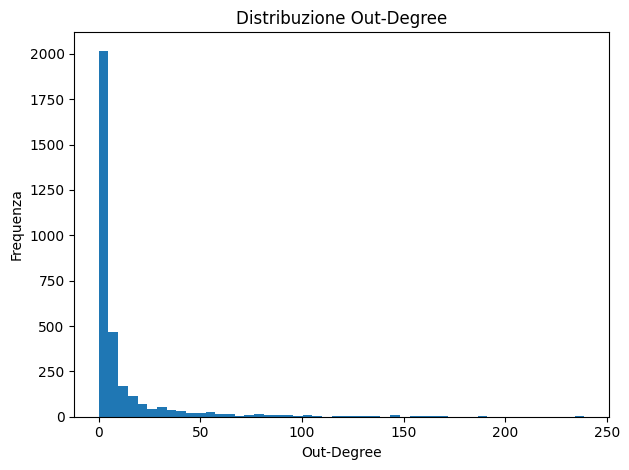

In [13]:
# distribuzione out-degree

plt.figure()
airport_df["out_degree"].plot(kind="hist", bins=50)
plt.title("Distribuzione Out-Degree")
plt.xlabel("Out-Degree")
plt.ylabel("Frequenza")
plt.tight_layout()
plt.show()

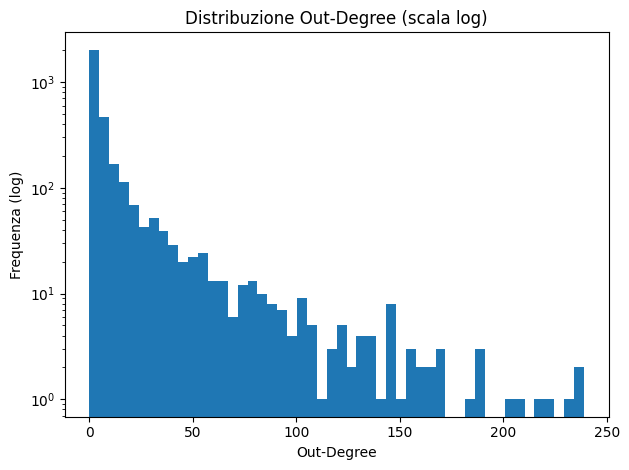

In [14]:
# distribuzione out-degree in scala logaritmica (valutare se tenere questa opzione con la scala logaritmica)

plt.figure()
airport_df["out_degree"].plot(kind="hist", bins=50, log=True)
plt.title("Distribuzione Out-Degree (scala log)")
plt.xlabel("Out-Degree")
plt.ylabel("Frequenza (log)")
plt.tight_layout()
plt.show()

In [15]:
 # top aeroporti per flussi in uscita (out-degree e out-strength)

TOP_N = 10

top_out = (
    airport_df
    .sort_values(["out_degree", "out_strength"], ascending=[False, False])
    .loc[:, ["airport_id", "name", "city", "country", "continent",
             "out_degree", "out_strength"]]
    .head(TOP_N)
)

top_out

,airport_id,name,city,country,continent,out_degree,out_strength
55,340,Frankfurt am Main Airport,Frankfurt,Germany,Europe,239,497
71,1382,Charles de Gaulle International Airport,Paris,France,Europe,237,524
65,580,Amsterdam Airport Schiphol,Amsterdam,Netherlands,Europe,232,453
334,1701,Atatürk International Airport,Istanbul,Turkey,Asia,224,354
266,3682,Hartsfield Jackson Atlanta International Airport,Atlanta,United States,North America,217,915
148,3830,Chicago O'Hare International Airport,Chicago,United States,North America,206,558
290,3364,Beijing Capital International Airport,Beijing,China,Asia,204,531
56,346,Munich Airport,Munich,Germany,Europe,191,368
147,3670,Dallas Fort Worth International Airport,Dallas-Fort Worth,United States,North America,187,469
485,4029,Domodedovo International Airport,Moscow,Russia,Europe,187,322


In [16]:
# top 10 aeroporti per flussi in entrata

TOP_N = 10

top_in = (
    airport_df
    .sort_values(["in_degree", "in_strength"], ascending=[False, False])
    .loc[:, ["airport_id", "name", "city", "country", "continent",
             "in_degree", "in_strength"]]
    .head(TOP_N)
)

top_in

,airport_id,name,city,country,continent,in_degree,in_strength
55,340,Frankfurt am Main Airport,Frankfurt,Germany,Europe,238,493
71,1382,Charles de Gaulle International Airport,Paris,France,Europe,233,517
65,580,Amsterdam Airport Schiphol,Amsterdam,Netherlands,Europe,231,450
334,1701,Atatürk International Airport,Istanbul,Turkey,Asia,227,357
266,3682,Hartsfield Jackson Atlanta International Airport,Atlanta,United States,North America,216,911
290,3364,Beijing Capital International Airport,Beijing,China,Asia,204,530
148,3830,Chicago O'Hare International Airport,Chicago,United States,North America,203,550
56,346,Munich Airport,Munich,Germany,Europe,189,360
485,4029,Domodedovo International Airport,Moscow,Russia,Europe,188,324
147,3670,Dallas Fort Worth International Airport,Dallas-Fort Worth,United States,North America,185,467


## Gerarchia globale degli aeroporti (Q2): PageRank e HITS



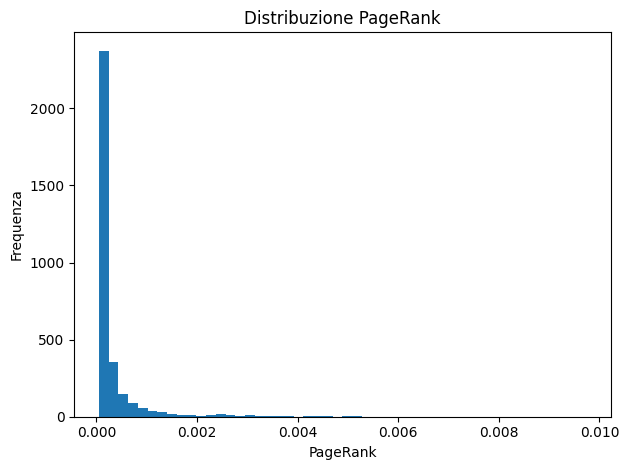

In [17]:
# distribuzione PageRank

plt.figure()
airport_df["pagerank"].plot(kind="hist", bins=50)
plt.title("Distribuzione PageRank")
plt.xlabel("PageRank")
plt.ylabel("Frequenza")
plt.tight_layout()
plt.show()

In [18]:
# ranking aeroporti per PageRank

top_pagerank = (
    airport_df
    .sort_values("pagerank", ascending=False)
    .loc[:, [
        "airport_id", "name", "city", "country",
        "continent", "pagerank", "community_id"
    ]]
    .head(10)
)

top_pagerank

,airport_id,name,city,country,continent,pagerank,community_id
266,3682,Hartsfield Jackson Atlanta International Airport,Atlanta,United States,North America,0.009737,0
148,3830,Chicago O'Hare International Airport,Chicago,United States,North America,0.006130,0
145,3484,Los Angeles International Airport,Los Angeles,United States,North America,0.005878,0
147,3670,Dallas Fort Worth International Airport,Dallas-Fort Worth,United States,North America,0.005628,0
71,1382,Charles de Gaulle International Airport,Paris,France,Europe,0.005139,1
62,507,London Heathrow Airport,London,United Kingdom,Europe,0.005120,0
19,3316,Singapore Changi Airport,Singapore,Singapore,Asia,0.005006,2
290,3364,Beijing Capital International Airport,Beijing,China,Asia,0.004920,2
78,3751,Denver International Airport,Denver,United States,North America,0.004913,0
55,340,Frankfurt am Main Airport,Frankfurt,Germany,Europe,0.004692,1


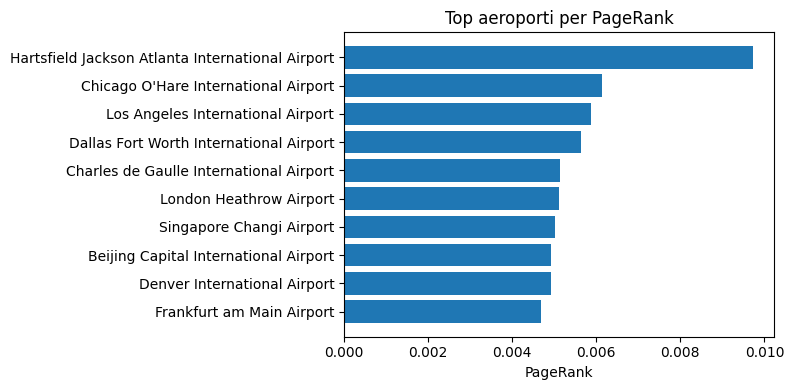

In [19]:
# barplot top PageRank

plt.figure(figsize=(8, 4))
plt.barh(
    top_pagerank["name"],
    top_pagerank["pagerank"]
)
plt.gca().invert_yaxis()
plt.title("Top aeroporti per PageRank")
plt.xlabel("PageRank")
plt.tight_layout()
plt.show()


In [20]:
# ranking aeroporti per HITS hub

top_hubs = (
    airport_df
    .sort_values("hits_hub", ascending=False)
    .loc[:, [
        "airport_id", "name", "city", "country",
        "continent", "hits_hub", "community_id"
    ]]
    .head(10)
)

top_hubs

,airport_id,name,city,country,continent,hits_hub,community_id
266,3682,Hartsfield Jackson Atlanta International Airport,Atlanta,United States,North America,0.015325,0
62,507,London Heathrow Airport,London,United Kingdom,Europe,0.011821,0
148,3830,Chicago O'Hare International Airport,Chicago,United States,North America,0.011447,0
79,3797,John F Kennedy International Airport,New York,United States,North America,0.010666,0
145,3484,Los Angeles International Airport,Los Angeles,United States,North America,0.010418,0
71,1382,Charles de Gaulle International Airport,Paris,France,Europe,0.008972,1
55,340,Frankfurt am Main Airport,Frankfurt,Germany,Europe,0.008098,1
147,3670,Dallas Fort Worth International Airport,Dallas-Fort Worth,United States,North America,0.007960,0
144,3469,San Francisco International Airport,San Francisco,United States,North America,0.007213,0
52,193,Lester B. Pearson International Airport,Toronto,Canada,North America,0.006930,0


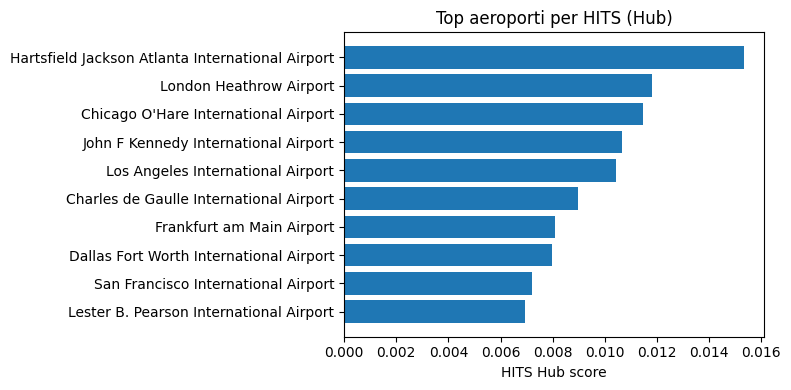

In [21]:
# barplot top aeroporti per HITS (hub)

TOP_N = 10

top_hubs_plot = (
    airport_df
    .sort_values("hits_hub", ascending=False)
    .head(TOP_N)
)

plt.figure(figsize=(8, 4))
plt.barh(
    top_hubs_plot["name"],
    top_hubs_plot["hits_hub"]
)
plt.gca().invert_yaxis()
plt.title("Top aeroporti per HITS (Hub)")
plt.xlabel("HITS Hub score")
plt.tight_layout()
plt.show()

In [22]:
# ranking aeroporti per HITS authority

top_authorities = (
    airport_df
    .sort_values("hits_authority", ascending=False)
    .loc[:, [
        "airport_id", "name", "city", "country",
        "continent", "hits_authority", "community_id"
    ]]
    .head(10)
)

top_authorities

,airport_id,name,city,country,continent,hits_authority,community_id
266,3682,Hartsfield Jackson Atlanta International Airport,Atlanta,United States,North America,0.015204,0
62,507,London Heathrow Airport,London,United Kingdom,Europe,0.011654,0
148,3830,Chicago O'Hare International Airport,Chicago,United States,North America,0.011262,0
79,3797,John F Kennedy International Airport,New York,United States,North America,0.010882,0
145,3484,Los Angeles International Airport,Los Angeles,United States,North America,0.010584,0
71,1382,Charles de Gaulle International Airport,Paris,France,Europe,0.008827,1
147,3670,Dallas Fort Worth International Airport,Dallas-Fort Worth,United States,North America,0.008168,0
55,340,Frankfurt am Main Airport,Frankfurt,Germany,Europe,0.007974,1
144,3469,San Francisco International Airport,San Francisco,United States,North America,0.007085,0
52,193,Lester B. Pearson International Airport,Toronto,Canada,North America,0.007020,0


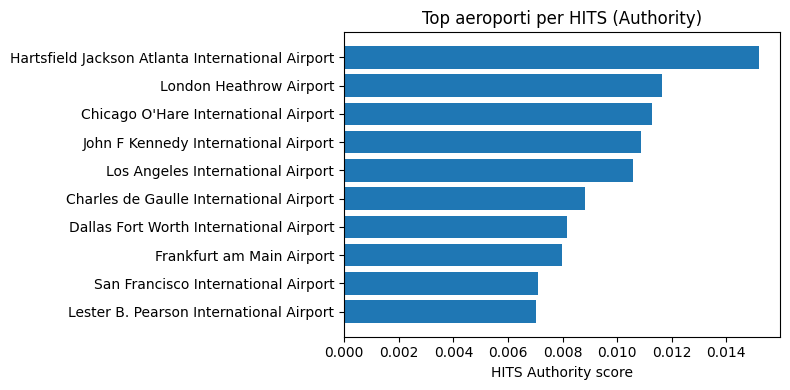

In [23]:
# barplot top aeroporti per HITS (Authority)

TOP_N = 10

top_authorities_plot = (
    airport_df
    .sort_values("hits_authority", ascending=False)
    .head(TOP_N)
)

plt.figure(figsize=(8, 4))
plt.barh(
    top_authorities_plot["name"],
    top_authorities_plot["hits_authority"]
)
plt.gca().invert_yaxis()
plt.title("Top aeroporti per HITS (Authority)")
plt.xlabel("HITS Authority score")
plt.tight_layout()
plt.show()

In [24]:
# confronto tra ranking PageRank, HITS hub e HITS authority

TOP_N = 10

pr_rank = (
    airport_df
    .sort_values("pagerank", ascending=False)
    .reset_index(drop=True)
    .reset_index(names="rank_pagerank")
    [["airport_id", "rank_pagerank"]]
)

hub_rank = (
    airport_df
    .sort_values("hits_hub", ascending=False)
    .reset_index(drop=True)
    .reset_index(names="rank_hub")
    [["airport_id", "rank_hub"]]
)

auth_rank = (
    airport_df
    .sort_values("hits_authority", ascending=False)
    .reset_index(drop=True)
    .reset_index(names="rank_authority")
    [["airport_id", "rank_authority"]]
)

rank_compare = (
    pr_rank
    .merge(hub_rank, on="airport_id", how="inner")
    .merge(auth_rank, on="airport_id", how="inner")
    .merge(
        airport_df[["airport_id", "name", "continent"]],
        on="airport_id",
        how="left"
    )
    .sort_values("rank_pagerank")
    .head(TOP_N)
)

rank_compare

,airport_id,rank_pagerank,rank_hub,rank_authority,name,continent
0,3682,0,0,0,Hartsfield Jackson Atlanta International Airport,North America
1,3830,1,2,2,Chicago O'Hare International Airport,North America
2,3484,2,4,4,Los Angeles International Airport,North America
3,3670,3,7,6,Dallas Fort Worth International Airport,North America
4,1382,4,5,5,Charles de Gaulle International Airport,Europe
5,507,5,1,1,London Heathrow Airport,Europe
6,3316,6,37,37,Singapore Changi Airport,Asia
7,3364,7,12,11,Beijing Capital International Airport,Asia
8,3751,8,13,13,Denver International Airport,North America
9,340,9,6,7,Frankfurt am Main Airport,Europe


# Visualizzazioni di rete


In [25]:
# selezione nodi top per PageRank + definizione "ruolo" via HITS

TOP_N = 40          # 30-50 è un range ottimo
ROLE_Q = 0.85       # top 10% per "hub" e "authority" (puoi cambiare)

top_nodes_df = (
    airport_df
    .sort_values("pagerank", ascending=False)
    .head(TOP_N)
    .copy()
)

hub_thr  = airport_df["hits_hub"].quantile(ROLE_Q)
auth_thr = airport_df["hits_authority"].quantile(ROLE_Q)

def role_code(row):
    is_hub = row["hits_hub"] >= hub_thr
    is_auth = row["hits_authority"] >= auth_thr
    # 0: neither, 1: hub only, 2: auth only, 3: both
    return int(is_hub) + 2*int(is_auth)

top_nodes_df["role"] = top_nodes_df.apply(role_code, axis=1)

print("Top nodes:", top_nodes_df.shape[0])
print("Role counts:\n", top_nodes_df["role"].value_counts().sort_index())
top_nodes_df[["airport_id","name","city","country","continent","pagerank","hits_hub","hits_authority","role","community_id"]].head()

Top nodes: 40
Role counts:
 role
3    40
Name: count, dtype: int64


,airport_id,name,city,country,continent,pagerank,hits_hub,hits_authority,role,community_id
266,3682,Hartsfield Jackson Atlanta International Airport,Atlanta,United States,North America,0.009737,0.015325,0.015204,3,0
148,3830,Chicago O'Hare International Airport,Chicago,United States,North America,0.006130,0.011447,0.011262,3,0
145,3484,Los Angeles International Airport,Los Angeles,United States,North America,0.005878,0.010418,0.010584,3,0
147,3670,Dallas Fort Worth International Airport,Dallas-Fort Worth,United States,North America,0.005628,0.007960,0.008168,3,0
71,1382,Charles de Gaulle International Airport,Paris,France,Europe,0.005139,0.008972,0.008827,3,1


In [26]:
# ricerca e caricamento edge-list (rotte) da percorsi comuni

CANDIDATE_EDGE_PATHS = [
    OUTPUT_DIR / "edges.csv",
    OUTPUT_DIR / "edge_list.csv",
    OUTPUT_DIR / "routes_edges.csv",
    Path("dataset/cleaned") / "routes_cleaned.csv",
    Path("dataset/cleaned") / "routes.csv",
    Path("dataset/cleaned") / "routes_airports_merged.csv",
    Path("dataset/cleaned") / "merged_routes_airports.csv",
    Path("dataset/cleaned/outputs") / "routes_cleaned.csv",
]

def load_edges():
    for p in CANDIDATE_EDGE_PATHS:
        if p.exists():
            df = pd.read_csv(p)
            print("Edge-list trovata:", p)
            return df, p
    return None, None

edges_df, edges_path = load_edges()

if edges_df is None:
    print(
        "Nessuna edge-list trovata.\n"
        "Per disegnare il grafo servono gli archi (rotte) in un CSV con colonne tipo:\n"
        "- source_airport_id, target_airport_id (o source/target)\n"
        "Se vuoi, poi ti dico esattamente come esportarla da network.py in outputs/ (edges.csv)."
    )
else:
    print("Shape edges_df:", edges_df.shape)
    print("Colonne disponibili:", list(edges_df.columns))
    edges_df.head()

Edge-list trovata: dataset/cleaned/routes_cleaned.csv
Shape edges_df: (67240, 5)
Colonne disponibili: ['airline', 'airline_id', 'source_airport_id', 'destination_airport_id', 'stops']


In [27]:
# Fix colonne edge-list: standardizzo source/target

edges_df = edges_df.copy()

# source
if "source_airport_id" in edges_df.columns:
    edges_df["source_airport_id"] = edges_df["source_airport_id"]
else:
    raise ValueError("Manca source_airport_id nella edge-list")

# target: nel tuo caso è destination_airport_id
if "destination_airport_id" in edges_df.columns and "target_airport_id" not in edges_df.columns:
    edges_df["target_airport_id"] = edges_df["destination_airport_id"]

print("Colonne edge-list dopo standardizzazione:", list(edges_df.columns))
edges_df[["source_airport_id", "target_airport_id"]].head()

Colonne edge-list dopo standardizzazione: ['airline', 'airline_id', 'source_airport_id', 'destination_airport_id', 'stops', 'target_airport_id']


,source_airport_id,target_airport_id
0,2965,2990
1,2966,2990
2,2966,2962
3,2968,2990
4,2968,4078


In [28]:
# aggregazione archi duplicati (peso = quante righe nella edge-list)

top_ids = set(top_nodes_df["airport_id"])

sub_edges = edges_df[
    edges_df["source_airport_id"].isin(top_ids) &
    edges_df["target_airport_id"].isin(top_ids)
].copy()

edge_w = (
    sub_edges
    .groupby(["source_airport_id", "target_airport_id"])
    .size()
    .reset_index(name="weight")
)

G_top = nx.DiGraph()

for _, r in top_nodes_df.iterrows():
    G_top.add_node(
        int(r["airport_id"]),
        name=r.get("name", ""),
        iata=r.get("iata", ""),
        pagerank=float(r["pagerank"]),
        hits_hub=float(r["hits_hub"]),
        hits_authority=float(r["hits_authority"]),
        role=int(r["role"]),
        latitude=float(r["latitude"]),
        longitude=float(r["longitude"]),
    )

for _, r in edge_w.iterrows():
    G_top.add_edge(int(r["source_airport_id"]), int(r["target_airport_id"]), weight=float(r["weight"]))

print("Nodes:", G_top.number_of_nodes(), "Edges:", G_top.number_of_edges())

Nodes: 40 Edges: 896


Salvato: dataset/cleaned/outputs/figures/graph_top_40_pagerank_spring_clean.png


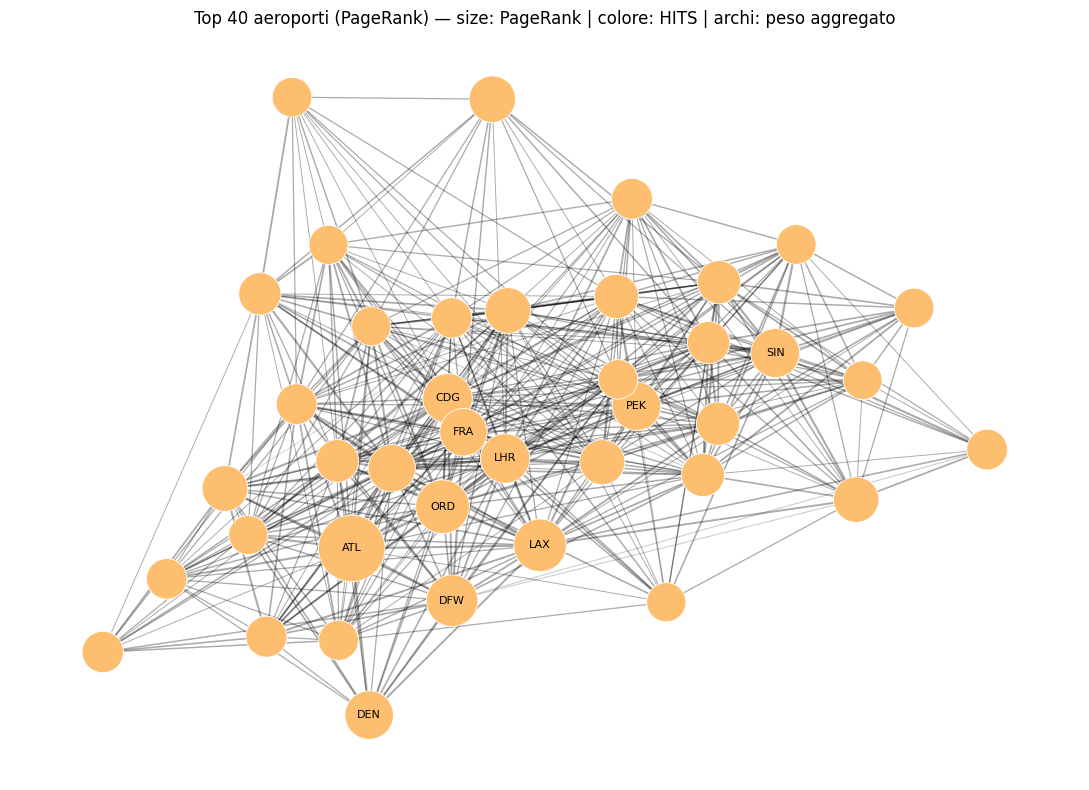

In [29]:
# disegno grafo top nodi (salvataggio in outputs/figures)

plt.figure(figsize=(11, 8))
pos = nx.spring_layout(G_top, seed=42, k=0.4)

# size = PageRank
pr_vals = np.array([G_top.nodes[n]["pagerank"] for n in G_top.nodes()])
node_sizes = 2200 * (pr_vals / pr_vals.max() + 0.05)

# colore = ruolo HITS (palette tenue)
# 0 neither, 1 hub, 2 authority, 3 both
role_vals = [G_top.nodes[n]["role"] for n in G_top.nodes()]
role_to_color = {0:"#d9d9d9", 1:"#a6cee3", 2:"#b2df8a", 3:"#fdbf6f"}  # chiari/tenui
node_colors = [role_to_color[r] for r in role_vals]

# spessore archi = log(1+weight)
w = np.array([G_top[u][v]["weight"] for u,v in G_top.edges()])
edge_widths = 0.3 + 1.6 * (np.log1p(w) / np.log1p(w.max()))
nx.draw_networkx_edges(G_top, pos, alpha=0.18, width=edge_widths, arrows=False)

nx.draw_networkx_nodes(G_top, pos, node_size=node_sizes, node_color=node_colors, edgecolors="white", linewidths=0.6)

# labels solo top 10 PageRank
top10_ids = set(top_nodes_df.sort_values("pagerank", ascending=False).head(10)["airport_id"])
labels = {}
for n in G_top.nodes():
    if n in top10_ids:
        iata = G_top.nodes[n].get("iata", "")
        name = G_top.nodes[n].get("name", "")
        labels[n] = iata if (isinstance(iata, str) and iata.strip()) else name

nx.draw_networkx_labels(G_top, pos, labels=labels, font_size=8)

plt.title("Top 40 aeroporti (PageRank) — size: PageRank | colore: HITS | archi: peso aggregato")
plt.axis("off")
plt.tight_layout()

out_path = FIG_DIR / f"graph_top_{TOP_N}_pagerank_spring_clean.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
print("Salvato:", out_path)

plt.show()

In [30]:
# filtro archi per peso minimo

MIN_W = 3  # prova 2; se resta troppo denso alza a 3

G_top_f = nx.DiGraph()
G_top_f.add_nodes_from(G_top.nodes(data=True))

# tieni solo archi con weight >= MIN_W
kept = 0
for u, v, data in G_top.edges(data=True):
    w = data.get("weight", 1.0)
    if w >= MIN_W:
        G_top_f.add_edge(u, v, **data)
        kept += 1

print("Archi originali:", G_top.number_of_edges())
print("Archi dopo filtro:", G_top_f.number_of_edges(), f"(MIN_W={MIN_W})")

Archi originali: 896
Archi dopo filtro: 491 (MIN_W=3)


In [31]:
# filtro "Top-K archi per nodo" (per migliorare la leggibilità della mappa)

K = 4

# partiamo dal grafo già filtrato per peso (MIN_W=3)
G_src = G_top_f

G_top_k = nx.DiGraph()
G_top_k.add_nodes_from(G_src.nodes(data=True))

# per ogni nodo, tengo solo i K archi uscenti con weight più alto
for u in G_src.nodes():
    out_edges = list(G_src.out_edges(u, data=True))
    if not out_edges:
        continue

    out_edges_sorted = sorted(
        out_edges,
        key=lambda x: x[2].get("weight", 1.0),
        reverse=True
    )[:K]

    for u2, v2, data in out_edges_sorted:
        G_top_k.add_edge(u2, v2, **data)

print("Archi G_top_f:", G_src.number_of_edges())
print(f"Archi G_top_k (K={K}):", G_top_k.number_of_edges())

Archi G_top_f: 491
Archi G_top_k (K=4): 158


Salvato: dataset/cleaned/outputs/figures/graph_top_40_pagerank_worldmap_greatcircle_TOPK4.png


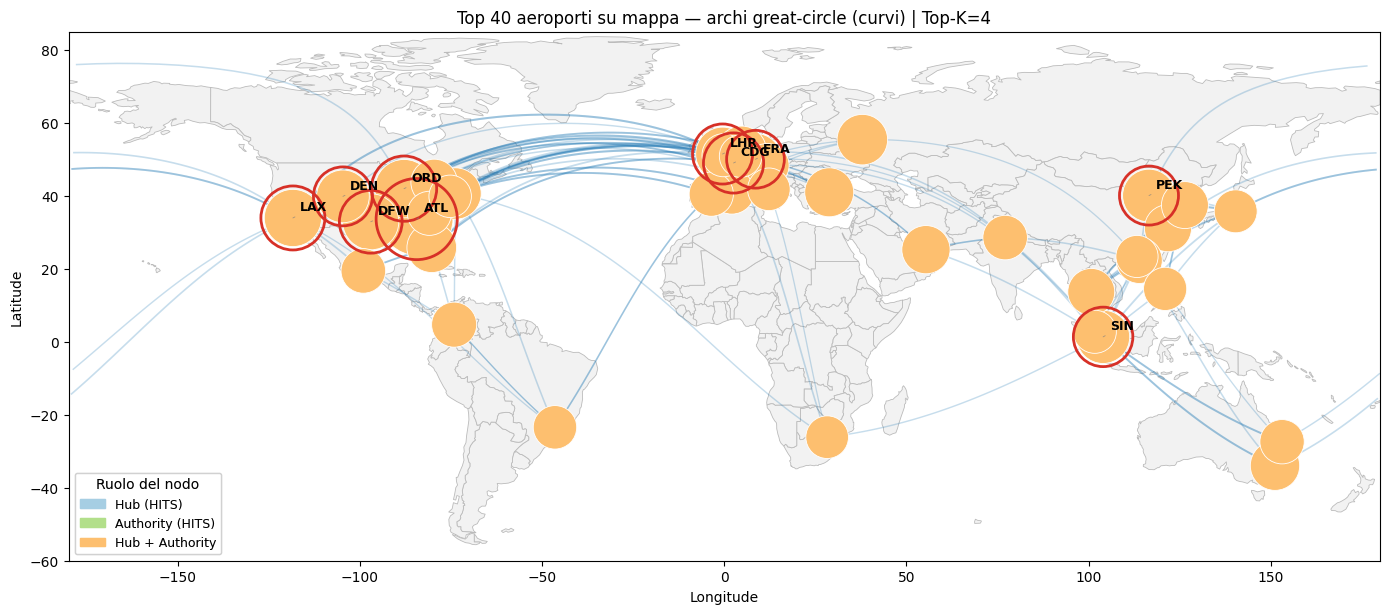

In [102]:
# mappa finale con archi "great-circle"

G = G_top_k   # <-- usa Top-K (consigliato per la mappa finale)

WORLD_ZIP = Path("assets/maps/ne_110m_admin_0_countries.zip")
world = gpd.read_file(WORLD_ZIP)

def great_circle(lon1, lat1, lon2, lat2, n=60):
    lon1r, lat1r = np.radians([lon1, lat1])
    lon2r, lat2r = np.radians([lon2, lat2])

    def to_vec(lonr, latr):
        return np.array([
            np.cos(latr) * np.cos(lonr),
            np.cos(latr) * np.sin(lonr),
            np.sin(latr)
        ])

    a = to_vec(lon1r, lat1r)
    b = to_vec(lon2r, lat2r)

    omega = np.arccos(np.clip(np.dot(a, b), -1.0, 1.0))
    if omega == 0:
        lons = np.linspace(lon1, lon2, n)
        lats = np.linspace(lat1, lat2, n)
        return np.column_stack([lons, lats])

    sin_omega = np.sin(omega)

    ts = np.linspace(0, 1, n)
    pts = []
    for t in ts:
        v = (np.sin((1-t)*omega) / sin_omega) * a + (np.sin(t*omega) / sin_omega) * b
        # back to lon/lat
        lon = np.degrees(np.arctan2(v[1], v[0]))
        lat = np.degrees(np.arcsin(np.clip(v[2], -1.0, 1.0)))
        pts.append((lon, lat))
    return np.array(pts)

plt.figure(figsize=(14, 7))
ax = plt.gca()

world.plot(
    ax=ax,
    color="#f2f2f2",
    edgecolor="#bbbbbb",
    linewidth=0.6,
    zorder=0
)

pos_geo = {n: (G.nodes[n]["longitude"], G.nodes[n]["latitude"]) for n in G.nodes()}

segments = []
edge_w = []

for u, v, data in G.edges(data=True):
    lon1, lat1 = pos_geo[u]
    lon2, lat2 = pos_geo[v]

    pts = great_circle(lon1, lat1, lon2, lat2, n=70)

    jumps = np.abs(np.diff(pts[:, 0]))
    cut_idx = np.where(jumps > 180)[0]
    if len(cut_idx) > 0:
        i = cut_idx[0] + 1
        part1 = pts[:i]
        part2 = pts[i:]
        if len(part1) > 1:
            segments.append(part1)
            edge_w.append(data.get("weight", 1.0))
        if len(part2) > 1:
            segments.append(part2)
            edge_w.append(data.get("weight", 1.0))
    else:
        segments.append(pts)
        edge_w.append(data.get("weight", 1.0))

edge_w = np.array(edge_w)
lw = 0.3 + 1.4 * (np.log1p(edge_w) / np.log1p(edge_w.max()))

lc = LineCollection(
    segments,
    linewidths=lw,
    alpha=0.25,
    color="#1f78b4",
    zorder=1
)
ax.add_collection(lc)

role_to_color = {0:"#d9d9d9", 1:"#a6cee3", 2:"#b2df8a", 3:"#fdbf6f"}

xs = [pos_geo[n][0] for n in G.nodes()]
ys = [pos_geo[n][1] for n in G.nodes()]

pr_vals = np.array([G.nodes[n]["pagerank"] for n in G.nodes()])
sizes = 2600 * (pr_vals / pr_vals.max() + 0.05)

roles = [G.nodes[n]["role"] for n in G.nodes()]
colors = [role_to_color[r] for r in roles]

ax.scatter(xs, ys, s=sizes, c=colors, edgecolors="white", linewidths=0.6, zorder=2)

highlight_nodes = [n for n in G.nodes() if n in top10_ids]

hx = [pos_geo[n][0] for n in highlight_nodes]
hy = [pos_geo[n][1] for n in highlight_nodes]

h_sizes = [
    1.25 * (2600 * (G.nodes[n]["pagerank"] / pr_vals.max() + 0.05))
    for n in highlight_nodes
]

ax.scatter(
    hx, hy,
    s=h_sizes,
    facecolors="none",
    edgecolors="#d73027",   # rosso tenue
    linewidths=2.0,
    zorder=4
)

for n in top10_ids:
    if n not in pos_geo:
        continue
    x, y = pos_geo[n]
    lab = labels.get(n, "")
    if lab:
        ax.annotate(
            lab,
            xy=(x, y),
            xytext=(x + 2.0, y + 2.0),
            textcoords="data",
            fontsize=9,
            fontweight="bold",
            arrowprops=dict(
                arrowstyle="-",
                color="gray",
                linewidth=0.6,
                alpha=0.7
            ),
            zorder=5
        )

ax.set_title("Top 40 aeroporti su mappa — archi great-circle (curvi) | Top-K=4")
ax.set_xlim(-180, 180)
ax.set_ylim(-60, 85)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()

legend_nodes = [
    mpatches.Patch(color=role_to_color[1], label="Hub (HITS)"),
    mpatches.Patch(color=role_to_color[2], label="Authority (HITS)"),
    mpatches.Patch(color=role_to_color[3], label="Hub + Authority"),
]

leg1 = ax.legend(
    handles=legend_nodes,
    title="Ruolo del nodo",
    loc="lower left",
    frameon=True,
    fontsize=9,
    title_fontsize=10
)
ax.add_artist(leg1)

out_path = FIG_DIR / f"graph_top_{TOP_N}_pagerank_worldmap_greatcircle_TOPK4.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
print("Salvato:", out_path)

plt.show()

## Q2 — Hub regionali per continente (Top PageRank)

In [103]:
# Top 5 aeroporti per continente (PageRank)

TOP_PER_CONT = 5

# sicurezza: tolgo righe senza continente o pagerank
df = airport_df.dropna(subset=["continent", "pagerank"]).copy()

top_by_cont = (
    df.sort_values(["continent", "pagerank"], ascending=[True, False])
      .groupby("continent", as_index=False)
      .head(TOP_PER_CONT)
      .copy()
)

print("Nodi selezionati totali:", top_by_cont.shape[0])
print("Continent counts:\n", top_by_cont["continent"].value_counts())

top_by_cont = top_by_cont.loc[:, [
    "airport_id", "name", "iata", "city", "country", "continent",
    "pagerank", "hits_hub", "hits_authority"
]].sort_values(["continent", "pagerank"], ascending=[True, False])

top_by_cont

Nodi selezionati totali: 30
Continent counts:
 continent
Africa           5
Asia             5
Europe           5
North America    5
Oceania          5
South America    5
Name: count, dtype: int64


,airport_id,name,iata,city,country,continent,pagerank,hits_hub,hits_authority
445,813,OR Tambo International Airport,JNB,Johannesburg,South Africa,Africa,0.003043,0.001792,0.001879
440,4059,Jomo Kenyatta International Airport,NBO,Nairobi,Kenya,Africa,0.002122,0.001198,0.001145
328,1107,Addis Ababa Bole International Airport,ADD,Addis Ababa,Ethiopia,Africa,0.001797,0.000937,0.001045
329,1128,Cairo International Airport,CAI,Cairo,Egypt,Africa,0.001728,0.001954,0.001951
237,1074,Mohammed V International Airport,CMN,Casablanca,Morocco,Africa,0.001466,0.001726,0.001733
19,3316,Singapore Changi Airport,SIN,Singapore,Singapore,Asia,0.005006,0.004624,0.004656
290,3364,Beijing Capital International Airport,PEK,Beijing,China,Asia,0.004920,0.006649,0.006654
334,1701,Atatürk International Airport,ISL,Istanbul,Turkey,Asia,0.004172,0.003778,0.003787
347,2188,Dubai International Airport,DXB,Dubai,United Arab Emirates,Asia,0.004028,0.004344,0.004418
292,3406,Shanghai Pudong International Airport,PVG,Shanghai,China,Asia,0.003820,0.006168,0.006247


Salvato: dataset/cleaned/outputs/figures/map_top5_per_continent_nodes_only.png


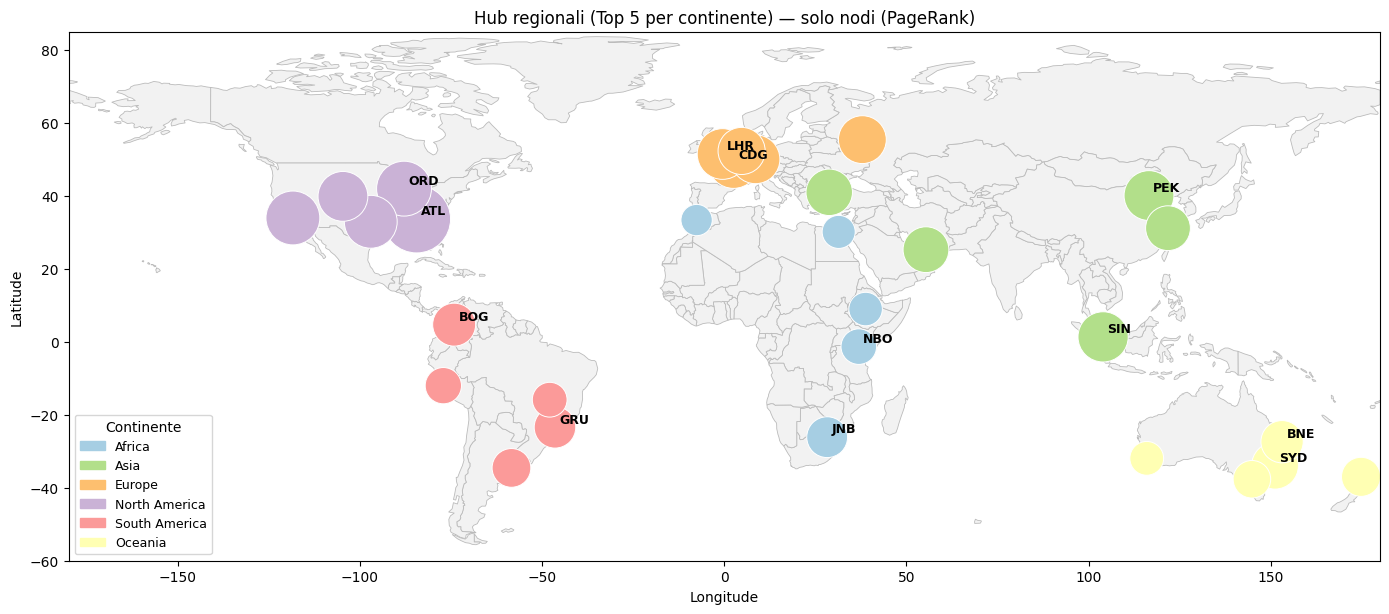

In [104]:
# Mappa hub per continente (solo nodi, senza archi)

TOP_PER_CONT = 5
LABEL_TOP_PER_CONT = 2   # etichetto solo i top 2 per continente (per pulizia)

# --- selezione top nodi per continente (PageRank) ---
df = airport_df.dropna(subset=["continent", "pagerank", "latitude", "longitude"]).copy()

top_by_cont = (
    df.sort_values(["continent", "pagerank"], ascending=[True, False])
      .groupby("continent", as_index=False)
      .head(TOP_PER_CONT)
      .copy()
)

# --- mappa offline ---
WORLD_ZIP = Path("assets/maps/ne_110m_admin_0_countries.zip")
world = gpd.read_file(WORLD_ZIP)

# --- colori per continente (chiari) ---
cont_colors = {
    "Africa": "#a6cee3",
    "Asia": "#b2df8a",
    "Europe": "#fdbf6f",
    "North America": "#cab2d6",
    "South America": "#fb9a99",
    "Oceania": "#ffffb3",
}

# --- plot ---
plt.figure(figsize=(14, 7))
ax = plt.gca()

world.plot(ax=ax, color="#f2f2f2", edgecolor="#bbbbbb", linewidth=0.6, zorder=0)

# nodi
xs = top_by_cont["longitude"].values
ys = top_by_cont["latitude"].values

pr = top_by_cont["pagerank"].values
sizes = 2200 * (pr / pr.max() + 0.08)

colors = [cont_colors.get(c, "#d9d9d9") for c in top_by_cont["continent"]]

ax.scatter(xs, ys, s=sizes, c=colors, edgecolors="white", linewidths=0.7, zorder=2)

# etichette (top 2 per continente)
lab_df = (
    top_by_cont.sort_values(["continent", "pagerank"], ascending=[True, False])
              .groupby("continent", as_index=False)
              .head(LABEL_TOP_PER_CONT)
)

for _, r in lab_df.iterrows():
    lab = r["iata"] if isinstance(r.get("iata", ""), str) and r["iata"].strip() else r.get("name", "")
    ax.text(r["longitude"] + 1.2, r["latitude"] + 1.2, lab, fontsize=9, fontweight="bold", zorder=3)

# legenda continenti
legend_handles = [mpatches.Patch(color=cont_colors[k], label=k) for k in cont_colors.keys()]
ax.legend(handles=legend_handles, title="Continente", loc="lower left", frameon=True, fontsize=9, title_fontsize=10)

ax.set_title("Hub regionali (Top 5 per continente) — solo nodi (PageRank)")
ax.set_xlim(-180, 180)
ax.set_ylim(-60, 85)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()

out_path = FIG_DIR / "map_top5_per_continent_nodes_only.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
print("Salvato:", out_path)

plt.show()

## Pattern direzionali dei flussi tra continenti (Q3)

In [32]:
# dataset di lavoro (continenti)

continent_dir = continent_directional.copy()
continent_flw = continent_flows.copy()

continent_dir, continent_flw.head()

(       continent  out_flow  in_flow  net_flow  out_in_ratio
 0         Africa      3144     3150        -6      0.998095
 1           Asia     20444    20445        -1      0.999951
 2         Europe     18906    18908        -2      0.999894
 3  North America     17063    17048        15      1.000880
 4        Oceania      1932     1939        -7      0.996390
 5  South America      2770     2769         1      1.000361,
   source_continent target_continent  flow
 0           Africa           Africa  1966
 1           Africa             Asia   358
 2           Africa           Europe   787
 3           Africa    North America    21
 4           Africa          Oceania     5)

In [33]:
# flussi in/out per continente

continent_dir_sorted = continent_dir.sort_values("out_flow", ascending=False)
continent_dir_sorted

,continent,out_flow,in_flow,net_flow,out_in_ratio
1,Asia,20444,20445,-1,0.999951
2,Europe,18906,18908,-2,0.999894
3,North America,17063,17048,15,1.000880
0,Africa,3144,3150,-6,0.998095
5,South America,2770,2769,1,1.000361
4,Oceania,1932,1939,-7,0.996390


In [34]:
# ranking continenti per flussi

continent_dir_sorted = continent_dir.sort_values("in_flow", ascending=False)
continent_dir_sorted

,continent,out_flow,in_flow,net_flow,out_in_ratio
1,Asia,20444,20445,-1,0.999951
2,Europe,18906,18908,-2,0.999894
3,North America,17063,17048,15,1.000880
0,Africa,3144,3150,-6,0.998095
5,South America,2770,2769,1,1.000361
4,Oceania,1932,1939,-7,0.996390


In [23]:
# Step 6.2 - bilanciamento dei flussi

continent_dir_sorted = continent_dir.sort_values("net_flow", ascending=False)
continent_dir_sorted

,continent,out_flow,in_flow,net_flow,out_in_ratio
3,North America,17063,17048,15,1.000880
5,South America,2770,2769,1,1.000361
1,Asia,20444,20445,-1,0.999951
2,Europe,18906,18908,-2,0.999894
0,Africa,3144,3150,-6,0.998095
4,Oceania,1932,1939,-7,0.996390


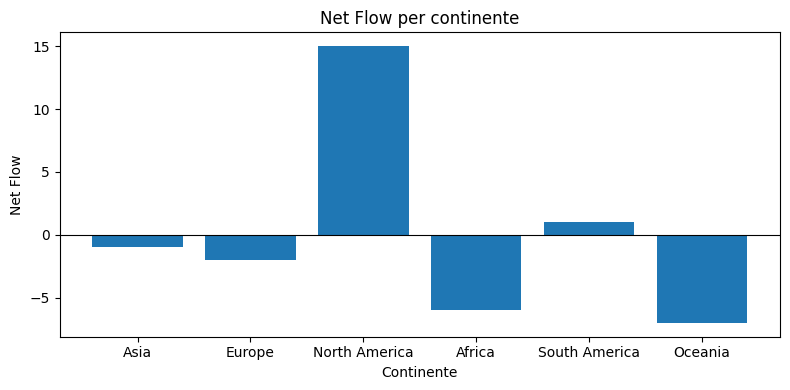

In [35]:
# visualizzazione net flow per continente

plt.figure(figsize=(8, 4))
plt.bar(
    continent_dir_sorted["continent"],
    continent_dir_sorted["net_flow"]
)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Net Flow per continente")
plt.xlabel("Continente")
plt.ylabel("Net Flow")
plt.tight_layout()
plt.show()

In [36]:
# matrice flussi intercontinentali

flow_matrix = continent_flw.pivot(
    index="source_continent",
    columns="target_continent",
    values="flow"
)

flow_matrix

target_continent,Africa,Asia,Europe,North America,Oceania,South America
source_continent,,,,,,
Africa,1966.0,358.0,787.0,21.0,5.0,7.0
Asia,356.0,17806.0,1695.0,334.0,248.0,5.0
Europe,792.0,1690.0,15360.0,971.0,NaN,93.0
North America,24.0,337.0,973.0,15382.0,58.0,289.0
Oceania,5.0,249.0,NaN,50.0,1623.0,5.0
South America,7.0,5.0,93.0,290.0,5.0,2370.0


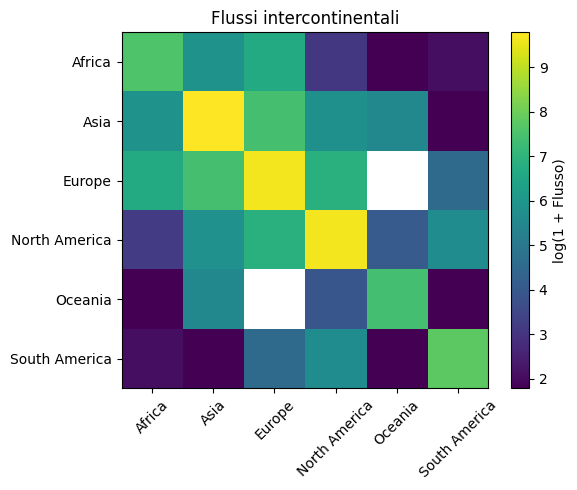

In [110]:
# heatmap flussi intercontinentali

plt.figure(figsize=(6, 5))
plt.imshow(np.log1p(flow_matrix), aspect="auto")
plt.colorbar(label="log(1 + Flusso)")
plt.xticks(range(len(flow_matrix.columns)), flow_matrix.columns, rotation=45)
plt.yticks(range(len(flow_matrix.index)), flow_matrix.index)
plt.title("Flussi intercontinentali")
plt.tight_layout()
plt.show()

# DA ELIMINARE

Salvato: dataset/cleaned/outputs/figures/graph_top5_per_continent_pagerank_worldmap.png


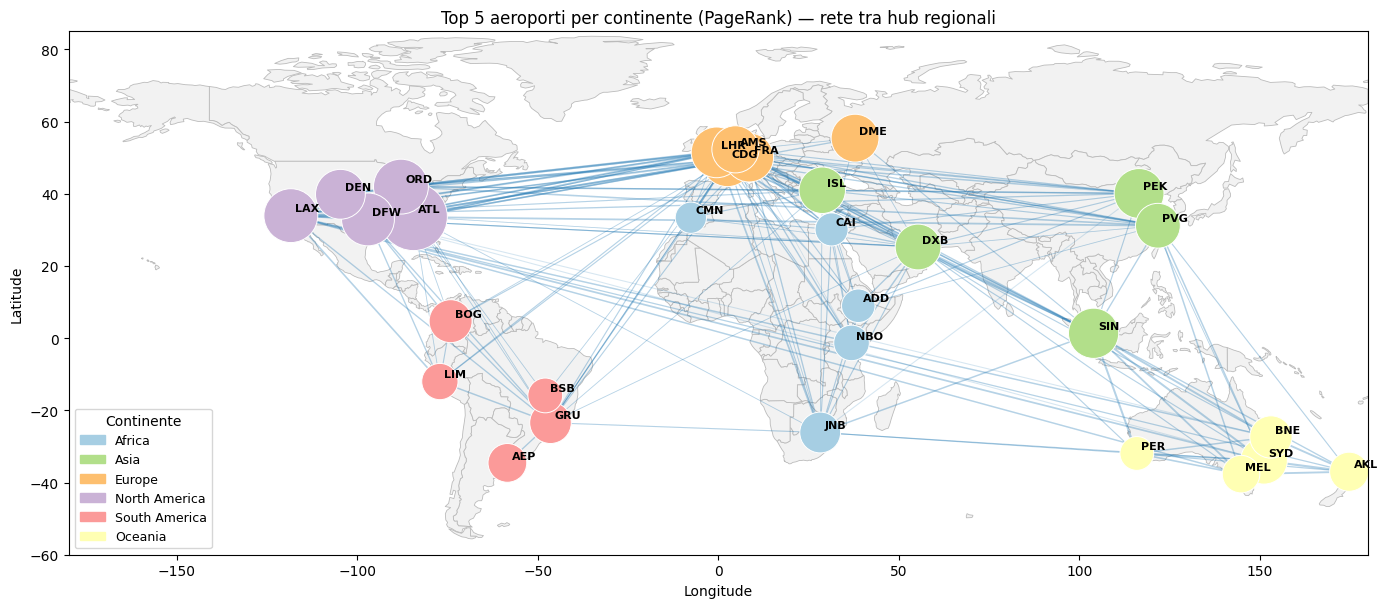

In [67]:
# ===== mappa offline =====
WORLD_ZIP = Path("assets/maps/ne_110m_admin_0_countries.zip")
world = gpd.read_file(WORLD_ZIP)

plt.figure(figsize=(14, 7))
ax = plt.gca()

world.plot(ax=ax, color="#f2f2f2", edgecolor="#bbbbbb", linewidth=0.6, zorder=0)

# ===== posizioni nodi =====
pos_geo = {n: (G_cont.nodes[n]["longitude"], G_cont.nodes[n]["latitude"]) for n in G_cont.nodes()}

# ===== colori per continente (palette chiara) =====
cont_colors = {
    "Africa": "#a6cee3",
    "Asia": "#b2df8a",
    "Europe": "#fdbf6f",
    "North America": "#cab2d6",
    "South America": "#fb9a99",
    "Oceania": "#ffffb3",
}

node_conts = [G_cont.nodes[n]["continent"] for n in G_cont.nodes()]
node_colors = [cont_colors.get(c, "#d9d9d9") for c in node_conts]

# ===== archi (linee dritte, qui vanno benissimo) =====
segments = []
edge_w = []

for u, v, data in G_cont.edges(data=True):
    x1, y1 = pos_geo[u]
    x2, y2 = pos_geo[v]
    segments.append([(x1, y1), (x2, y2)])
    edge_w.append(data.get("weight", 1.0))

edge_w = np.array(edge_w)
lw = 0.2 + 1.6 * (np.log1p(edge_w) / np.log1p(edge_w.max()))

lc = LineCollection(segments, linewidths=lw, alpha=0.18, color="#1f78b4", zorder=1)
ax.add_collection(lc)

# ===== nodi (size=PageRank) =====
pr_vals = np.array([G_cont.nodes[n]["pagerank"] for n in G_cont.nodes()])
sizes = 2200 * (pr_vals / pr_vals.max() + 0.08)

xs = [pos_geo[n][0] for n in G_cont.nodes()]
ys = [pos_geo[n][1] for n in G_cont.nodes()]

ax.scatter(xs, ys, s=sizes, c=node_colors, edgecolors="white", linewidths=0.7, zorder=2)

# ===== etichette: per 30 nodi possiamo usare IATA (più pulito) =====
for n in G_cont.nodes():
    x, y = pos_geo[n]
    lab = G_cont.nodes[n].get("iata", "")
    if not isinstance(lab, str) or not lab.strip():
        lab = G_cont.nodes[n].get("name", "")
    ax.text(x + 1.2, y + 1.2, lab, fontsize=8, fontweight="bold", zorder=3)

# ===== legenda continenti =====
legend_handles = [mpatches.Patch(color=cont_colors[k], label=k) for k in cont_colors.keys()]
ax.legend(handles=legend_handles, title="Continente", loc="lower left", frameon=True, fontsize=9, title_fontsize=10)

ax.set_title("Top 5 aeroporti per continente (PageRank) — rete tra hub regionali")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-180, 180)
ax.set_ylim(-60, 85)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()

out_path = FIG_DIR / "graph_top5_per_continent_pagerank_worldmap.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
print("Salvato:", out_path)

plt.show()
